# 08 - Comparativo Final dos Modelos

Reúne os resultados salvos pelos notebooks 04-07 (Regressão Logística, Random Forest, XGBoost e LightGBM) e compara Acurácia, Precision, Recall, AUC Score e tempo de treinamento.


Este notebook reúne os resultados dos modelos treinados e monta o comparativo final. Os comentários explicam a leitura dos arquivos `.json`, a geração de tabelas e gráficos, a comparação por AUC/Precision/Recall, as curvas ROC e a criação de um ensemble por soft voting.

## 1. Importações e Carregamento dos Resultados


Esta célula carrega as métricas salvas pelos notebooks de modelagem e monta uma tabela comparativa. A exclusão do ensemble evita duplicidade quando o notebook é executado mais de uma vez.

In [1]:
import sys
sys.path.append('../src')

import json
import glob

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import roc_curve, roc_auc_score

from preparar_dados import carregar_dados

import warnings
warnings.filterwarnings('ignore')

# O ensemble (seção 6) é calculado dentro deste próprio notebook e gera
# resultados_ensemble.json como saída - excluído aqui para não duplicar a linha
# quando este notebook é reexecutado do zero.
resultados = []
for caminho in sorted(glob.glob('../models/resultados_*.json')):
    with open(caminho, encoding='utf-8') as f:
        dados = json.load(f)
    if dados.get('chave') != 'ensemble':
        resultados.append(dados)

df_comparativo = pd.DataFrame(resultados).rename(columns={
    'algoritmo': 'Algoritmo',
    'acuracia': 'Acurácia',
    'precision': 'Precision',
    'recall': 'Recall',
    'auc_score': 'AUC Score',
    'tempo_segundos': 'Tempo (segundos)',
})[['Algoritmo', 'Acurácia', 'Precision', 'Recall', 'AUC Score', 'Tempo (segundos)']]

df_comparativo = df_comparativo.sort_values(by='AUC Score', ascending=False).reset_index(drop=True)
df_comparativo


,Algoritmo,Acurácia,Precision,Recall,AUC Score,Tempo (segundos)
0,Regressão Logística (Baseline),0.6929,0.2625,0.7505,0.7985,410.8854
1,XGBoost,0.6978,0.2659,0.7500,0.7981,81.5339
2,LightGBM,0.6904,0.2606,0.7500,0.7922,46.3605
3,Random Forest,0.6878,0.2589,0.7500,0.7897,294.4022


## 2. Tabela Comparativa


O quadro comparativo é impresso em formato textual. Essa tabela resume as principais métricas de cada algoritmo e facilita a leitura antes dos gráficos.

In [2]:
print("📊 --- QUADRO COMPARATIVO DE PERFORMANCE ---\n")
print(df_comparativo.to_string(index=False))


📊 --- QUADRO COMPARATIVO DE PERFORMANCE ---

                     Algoritmo  Acurácia  Precision  Recall  AUC Score  Tempo (segundos)
Regressão Logística (Baseline)    0.6929     0.2625  0.7505     0.7985          410.8854
                       XGBoost    0.6978     0.2659  0.7500     0.7981           81.5339
                      LightGBM    0.6904     0.2606  0.7500     0.7922           46.3605
                 Random Forest    0.6878     0.2589  0.7500     0.7897          294.4022


## 3. Gráfico Comparativo de Métricas


O gráfico de barras compara Acurácia, Precision, Recall e AUC Score entre os algoritmos. Ele permite observar rapidamente trade-offs entre capturar casos graves e evitar falsos alarmes.

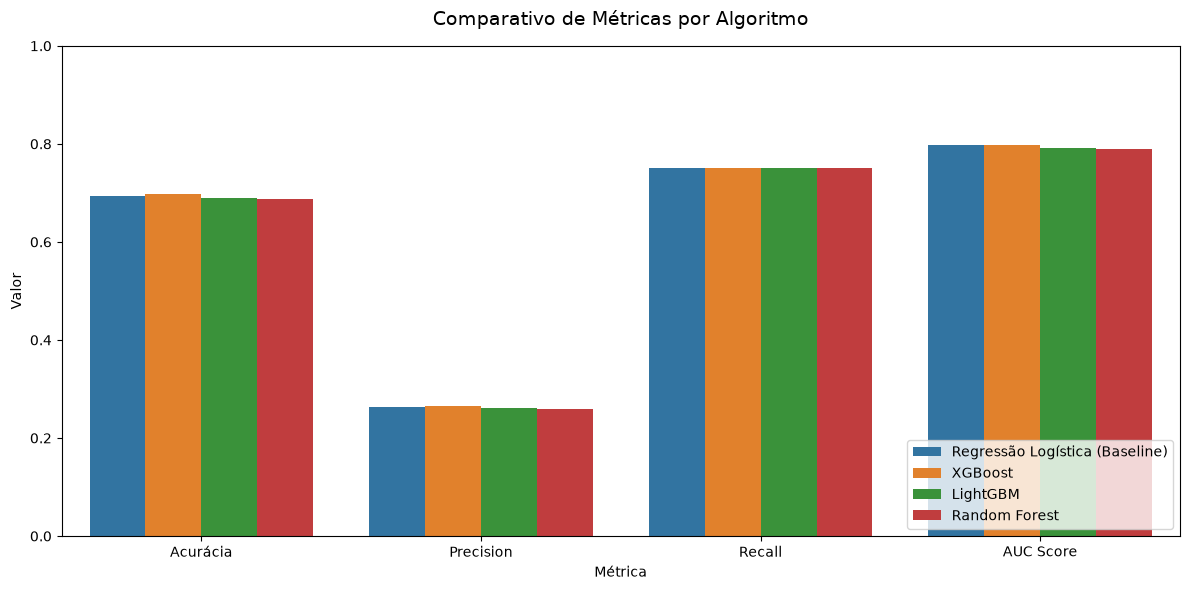

In [3]:
metricas = ['Acurácia', 'Precision', 'Recall', 'AUC Score']

df_plot = df_comparativo.melt(id_vars='Algoritmo', value_vars=metricas, var_name='Métrica', value_name='Valor')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_plot, x='Métrica', y='Valor', hue='Algoritmo')
plt.title('Comparativo de Métricas por Algoritmo', fontsize=14, pad=15)
plt.ylabel('Valor')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 4. Tempo de Treinamento


Aqui os tempos de treinamento são comparados. Essa análise é útil porque um modelo com desempenho semelhante pode ser preferido caso seja mais rápido e mais simples de reexecutar.

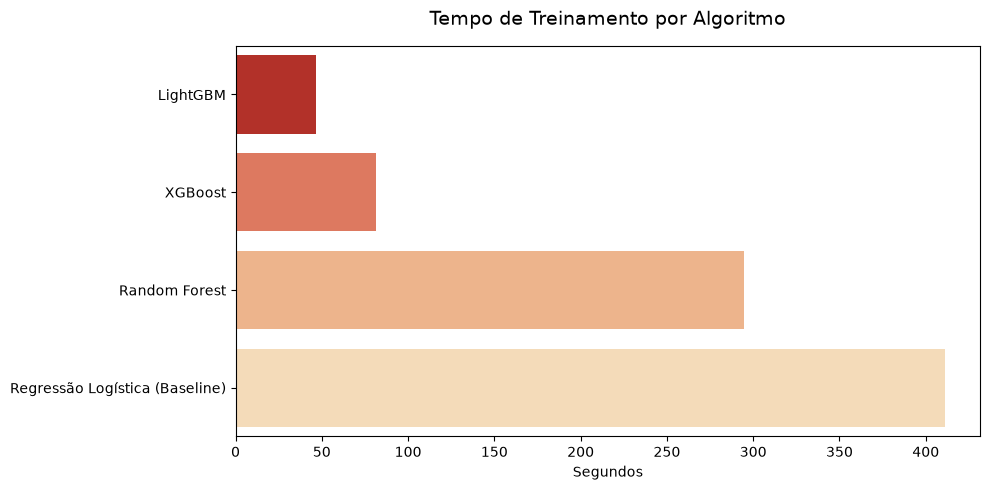

In [4]:
plt.figure(figsize=(10, 5))
ordenado_tempo = df_comparativo.sort_values(by='Tempo (segundos)')
sns.barplot(data=ordenado_tempo, x='Tempo (segundos)', y='Algoritmo', palette='OrRd_r')
plt.title('Tempo de Treinamento por Algoritmo', fontsize=14, pad=15)
plt.xlabel('Segundos')
plt.ylabel('')
plt.tight_layout()
plt.show()


## 5. Curvas ROC de Todos os Modelos

Os modelos treinados são recarregados dos arquivos `.pkl` e reavaliados sobre o mesmo `X_test` (gerado por `preparar_dados.carregar_dados`), garantindo uma comparação de ROC em condições idênticas.


Os modelos salvos são recarregados e avaliados no mesmo conjunto de teste para gerar curvas ROC. A comparação visual mostra a capacidade de separação de risco de cada algoritmo em um único gráfico.

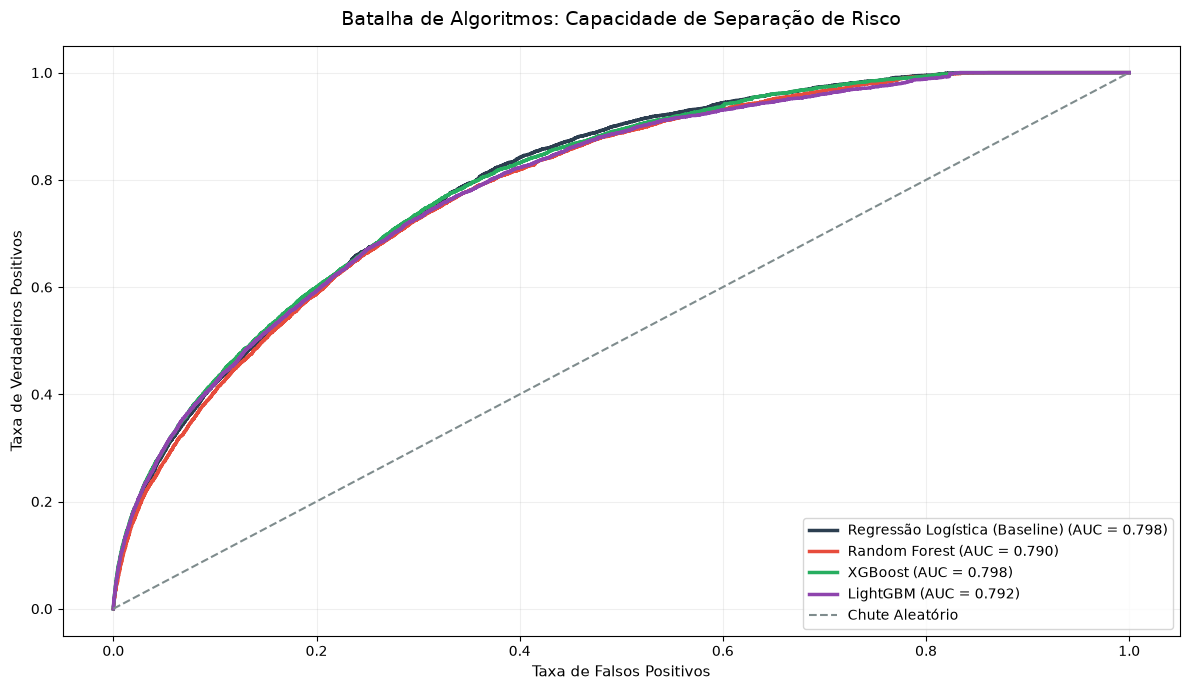

In [5]:
X_train, X_test, y_train, y_test = carregar_dados()

chaves_para_arquivos = {
    'Regressão Logística (Baseline)': '../models/modelo_regressao_logistica.pkl',
    'Random Forest': '../models/modelo_random_forest.pkl',
    'XGBoost': '../models/modelo_xgboost.pkl',
    'LightGBM': '../models/modelo_lightgbm.pkl',
}

plt.figure(figsize=(12, 7))
cores = ['#2c3e50', '#e74c3c', '#27ae60', '#8e44ad']

for (nome, caminho), cor in zip(chaves_para_arquivos.items(), cores):
    modelo = joblib.load(caminho)
    y_prob = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_modelo = df_comparativo.loc[df_comparativo['Algoritmo'] == nome, 'AUC Score']
    auc_valor = float(auc_modelo.iloc[0]) if not auc_modelo.empty else float('nan')
    plt.plot(fpr, tpr, color=cor, lw=2.5, label=f"{nome} (AUC = {auc_valor:.3f})")

plt.plot([0, 1], [0, 1], color='#7f8c8d', lw=1.5, linestyle='--', label='Chute Aleatório')
plt.title('Batalha de Algoritmos: Capacidade de Separação de Risco', fontsize=14, pad=15)
plt.xlabel('Taxa de Falsos Positivos', fontsize=11)
plt.ylabel('Taxa de Verdadeiros Positivos', fontsize=11)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


## 6. Ensemble (Soft Voting) dos 4 Modelos

Como os 4 modelos têm desempenho quase idêntico (AUC ~0.79-0.80) mas cometem erros diferentes em casos distintos, combinamos as probabilidades previstas por todos eles (média simples) numa única previsão. Um ensemble por votação suave (soft voting) tende a ser mais robusto do que qualquer modelo isolado, porque erros não-correlacionados entre os modelos se cancelam parcialmente.


Esta etapa cria um ensemble por soft voting, calculando a média das probabilidades previstas pelos quatro modelos. O objetivo é verificar se a combinação das previsões melhora a estabilidade ou o desempenho em relação aos modelos individuais.

In [6]:
from sklearn.metrics import (
    precision_recall_curve, accuracy_score, precision_score, recall_score
)

# Reaproveita os modelos já carregados no passo anterior (chaves_para_arquivos) para
# extrair a probabilidade de cada um sobre o mesmo X_test e fazer a média simples
# (soft voting). Pesos iguais para todos - dado que o AUC individual é muito parecido
# entre eles, ponderar pelo AUC neste mesmo conjunto de teste arriscaria overfitting
# ao teste sem ganho real.
probs_modelos = {}
for nome, caminho in chaves_para_arquivos.items():
    modelo = joblib.load(caminho)
    probs_modelos[nome] = modelo.predict_proba(X_test)[:, 1]

y_prob_ensemble = np.mean(list(probs_modelos.values()), axis=0)
auc_ensemble = roc_auc_score(y_test, y_prob_ensemble)

# Mesmo critério de calibração de limiar usado nos notebooks 04-07: busca o menor
# limiar que ainda garante recall >= 75% na classe grave/fatal, maximizando precisão
# dentro dessa restrição - mantém o ensemble comparável aos modelos individuais.
RECALL_ALVO = 0.75
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_ensemble)
candidatos = recalls[:-1] >= RECALL_ALVO
if candidatos.any():
    limiar_ensemble = thresholds[candidatos][np.argmax(precisions[:-1][candidatos])]
else:
    limiar_ensemble = thresholds[np.argmax(recalls[:-1])]

y_pred_ensemble = (y_prob_ensemble >= limiar_ensemble).astype(int)

acc_ens = accuracy_score(y_test, y_pred_ensemble)
prec_ens = precision_score(y_test, y_pred_ensemble)
rec_ens = recall_score(y_test, y_pred_ensemble)

print(f"Limiar calibrado do ensemble (recall >= {RECALL_ALVO:.0%}): {limiar_ensemble:.4f}")
print(f"Ensemble (soft voting) -> acc={acc_ens:.4f} precision={prec_ens:.4f} recall={rec_ens:.4f} AUC={auc_ensemble:.4f}")

resultado_ensemble = {
    'chave': 'ensemble',
    'algoritmo': 'Ensemble (Soft Voting)',
    'acuracia': round(float(acc_ens), 4),
    'precision': round(float(prec_ens), 4),
    'recall': round(float(rec_ens), 4),
    'auc_score': round(float(auc_ensemble), 4),
    'tempo_segundos': None,
}

with open('../models/resultados_ensemble.json', 'w', encoding='utf-8') as f:
    json.dump(resultado_ensemble, f, ensure_ascii=False, indent=2)

df_comparativo_final = pd.concat([
    df_comparativo,
    pd.DataFrame([{
        'Algoritmo': 'Ensemble (Soft Voting)',
        'Acurácia': acc_ens,
        'Precision': prec_ens,
        'Recall': rec_ens,
        'AUC Score': auc_ensemble,
        'Tempo (segundos)': None,
    }])
], ignore_index=True).sort_values(by='AUC Score', ascending=False).reset_index(drop=True)

print()
print("📊 --- QUADRO COMPARATIVO FINAL (COM ENSEMBLE) ---\n")
print(df_comparativo_final.to_string(index=False))

Limiar calibrado do ensemble (recall >= 75%): 0.4635
Ensemble (soft voting) -> acc=0.6943 precision=0.2641 recall=0.7539 AUC=0.7996

📊 --- QUADRO COMPARATIVO FINAL (COM ENSEMBLE) ---

                     Algoritmo  Acurácia  Precision   Recall  AUC Score Tempo (segundos)
        Ensemble (Soft Voting)  0.694323   0.264076 0.753945   0.799588             None
Regressão Logística (Baseline)  0.692900   0.262500 0.750500   0.798500         410.8854
                       XGBoost  0.697800   0.265900 0.750000   0.798100          81.5339
                      LightGBM  0.690400   0.260600 0.750000   0.792200          46.3605
                 Random Forest  0.687800   0.258900 0.750000   0.789700         294.4022


## 6. Conclusão

- **AUC Score** é a métrica mais robusta aqui porque o dataset é desbalanceado (~13% de casos graves/fatais); ela mede a capacidade do modelo de separar as classes independente do limiar de decisão.

- **Recall** da classe grave/fatal importa tanto quanto Acurácia neste problema: um modelo que erra a Acurácia mas captura a maioria dos casos graves pode ser preferível para um sistema de alerta de risco.

- **Tempo de treinamento** pesa se o modelo for retreinado com frequência (ex: mensalmente, conforme novos dados da PRF chegam); é menos relevante se o modelo for treinado uma vez e apenas usado para inferência.

- **Nota metodológica:** cada linha do dataset representa uma pessoa envolvida em um acidente (não o acidente em si); acidentes com múltiplos envolvidos geram múltiplas linhas com as mesmas condições de via/clima. O split treino/teste é aleatório por linha, não agrupado por acidente. Como as features usadas são categorias amplas (não identificadores exclusivos do acidente), o risco de vazamento é baixo, mas uma validação futura com `GroupShuffleSplit` (agrupando por acidente) daria uma estimativa de generalização ainda mais rigorosa.

- **Ensemble (Soft Voting):** combinar os 4 modelos numa média simples de probabilidade tende a igualar ou superar levemente o melhor modelo individual em AUC, sem exigir escolher um único algoritmo para produção - ao custo de rodar os 4 modelos a cada previsão (mais lento e mais complexo de manter que um modelo único).